In [2]:
# Load data and libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('../data/raw/power_plant.csv')

# Quick overview
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Dataset Shape: (9568, 5)

First 5 rows:
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90

Column names: ['AT', 'V', 'AP', 'RH', 'PE']

Data types:
 AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


In [4]:
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000


In [5]:
# Correlation matrix
print("Correlation Matrix:")
print(df.corr())

Correlation Matrix:
          AT         V        AP        RH        PE
AT  1.000000  0.844107 -0.507549 -0.542535 -0.948128
V   0.844107  1.000000 -0.413502 -0.312187 -0.869780
AP -0.507549 -0.413502  1.000000  0.099574  0.518429
RH -0.542535 -0.312187  0.099574  1.000000  0.389794
PE -0.948128 -0.869780  0.518429  0.389794  1.000000


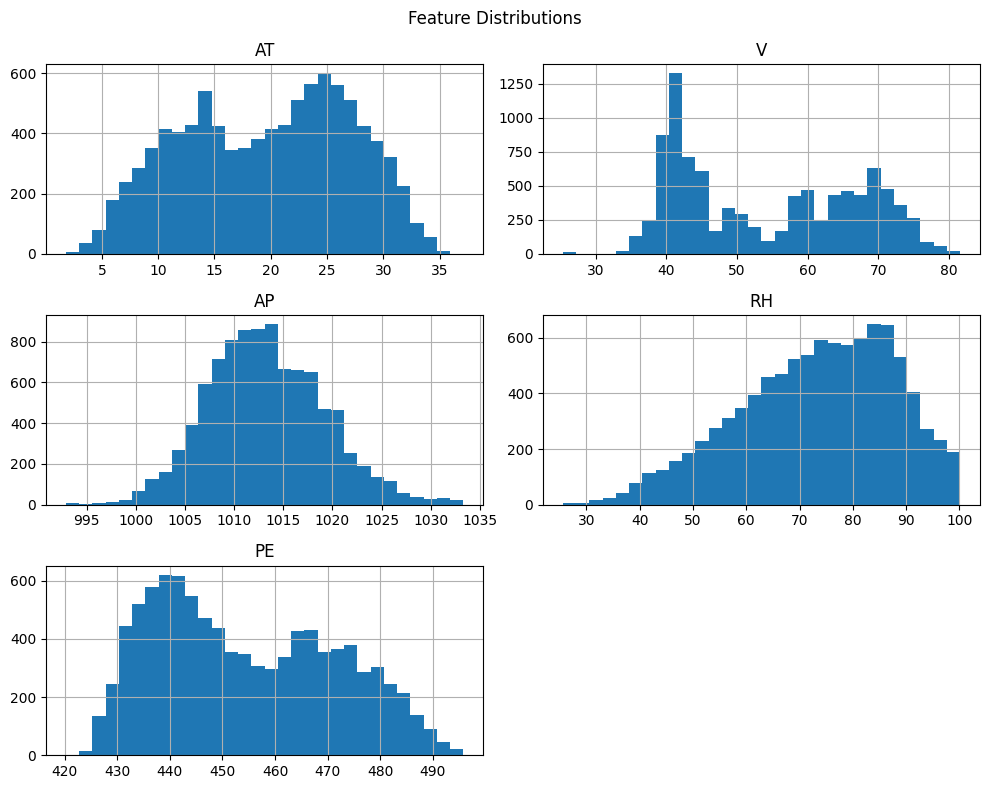

In [6]:
# Visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(10, 8), bins=30)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

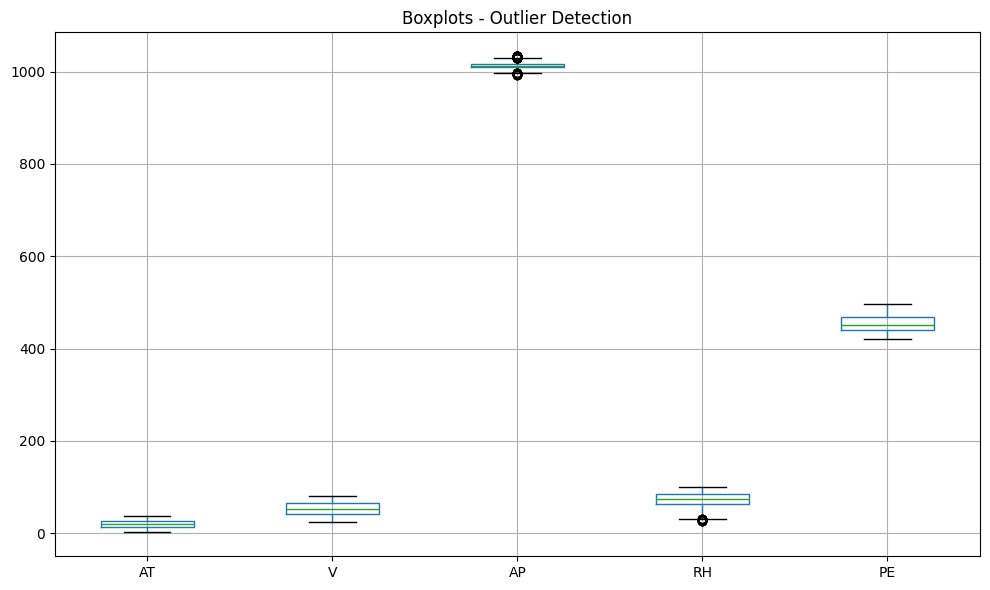

In [7]:
# Outlier detection using boxplots
df.boxplot(figsize=(10, 6))
plt.title('Boxplots - Outlier Detection')
plt.tight_layout()
plt.show()

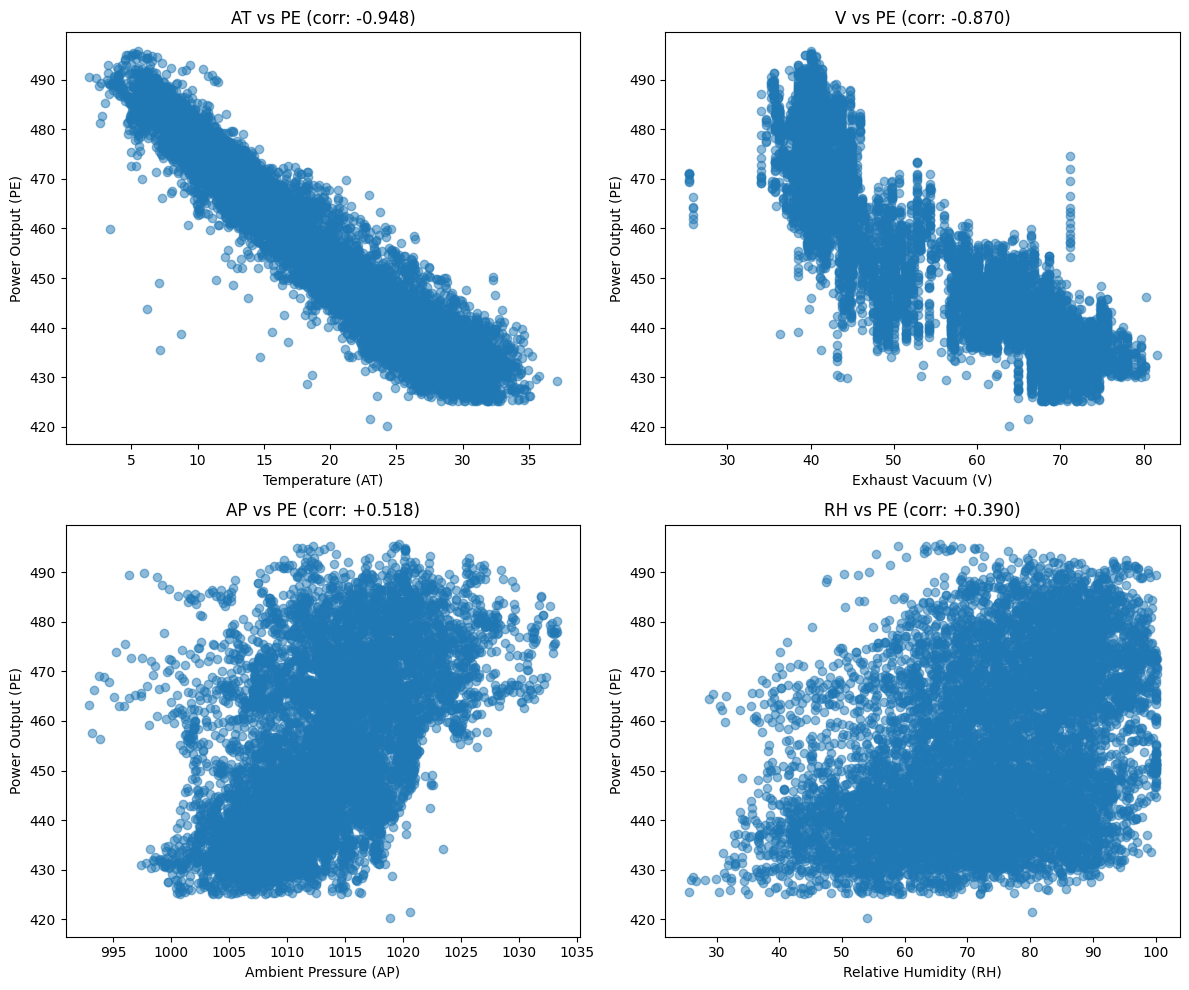

In [8]:
# Feature vs Target scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# AT vs PE
axes[0, 0].scatter(df['AT'], df['PE'], alpha=0.5)
axes[0, 0].set_xlabel('Temperature (AT)')
axes[0, 0].set_ylabel('Power Output (PE)')
axes[0, 0].set_title('AT vs PE (corr: -0.948)')

# V vs PE
axes[0, 1].scatter(df['V'], df['PE'], alpha=0.5)
axes[0, 1].set_xlabel('Exhaust Vacuum (V)')
axes[0, 1].set_ylabel('Power Output (PE)')
axes[0, 1].set_title('V vs PE (corr: -0.870)')

# AP vs PE
axes[1, 0].scatter(df['AP'], df['PE'], alpha=0.5)
axes[1, 0].set_xlabel('Ambient Pressure (AP)')
axes[1, 0].set_ylabel('Power Output (PE)')
axes[1, 0].set_title('AP vs PE (corr: +0.518)')

# RH vs PE
axes[1, 1].scatter(df['RH'], df['PE'], alpha=0.5)
axes[1, 1].set_xlabel('Relative Humidity (RH)')
axes[1, 1].set_ylabel('Power Output (PE)')
axes[1, 1].set_title('RH vs PE (corr: +0.390)')

plt.tight_layout()
plt.show()

In [9]:
print("Feature Analysis Summary:")
print("- AT: Strongest predictor (nearly linear relationship)")
print("- V: Strong negative relationship") 
print("- AP: Moderate positive relationship")
print("- RH: Weakest predictor (very scattered)")

Feature Analysis Summary:
- AT: Strongest predictor (nearly linear relationship)
- V: Strong negative relationship
- AP: Moderate positive relationship
- RH: Weakest predictor (very scattered)


In [11]:
print("Feature Analysis Summary:")
print("- AT: Strongest predictor (nearly linear relationship)")
print("- V: Strong negative relationship") 
print("- AP: Moderate positive relationship")
print("- RH: Weakest predictor (very scattered)")

Feature Analysis Summary:
- AT: Strongest predictor (nearly linear relationship)
- V: Strong negative relationship
- AP: Moderate positive relationship
- RH: Weakest predictor (very scattered)


## Physical Interpretation of Feature Relationships

**AT (Temperature) → PE (negative correlation -0.948):**
- Hot ambient air reduces gas turbine efficiency
- Lower air density = less oxygen for combustion
- More energy needed to compress hot air
- **Engineering principle:** Carnot efficiency decreases with higher intake temperature

**V (Vacuum) → PE (negative correlation -0.870):**
- Higher vacuum in condenser = lower steam turbine backpressure
- Better heat extraction from steam cycle
- More efficient energy conversion

**AP (Pressure) → PE (positive correlation +0.518):**
- Higher atmospheric pressure = denser air
- More oxygen available for combustion
- Better gas turbine performance

**RH (Humidity) → PE (weak positive correlation +0.390):**
- Humid air slightly increases mass flow through turbine
- Minor cooling effect on intake air
- Weakest effect among all variables